<a href="https://colab.research.google.com/github/pillisirichandana21/employee-attrition-analysis/blob/main/employee-attrition-analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# E-Commerce Sales & Customer Behavior Analysis

## 1. Project Overview

This project performs Exploratory Data Analysis (EDA) on the UCI Online Retail
Dataset.

The objective is to understand sales performance, customer purchasing behaviour,
product demand, and geographical distribution of customers.

## Problem Statement

An online retail company wants to understand:

- Sales performance
- Customer purchasing behaviour
- Product demand
- Geographical distribution of customers

## Key Questions

1. Which products generate the highest sales?
2. Which countries contribute the most revenue?
3. What are the monthly/weekly sales trends?
4. Which products have the highest quantity sold?
5. What is the average order value?
6. Who are the most valuable customers?
7. Are there unusual transactions or outliers?
8. What percentage of transactions are cancelled?
9. Which products show increasing or declining demand?
10. Is there a relationship between product price and quantity purchased?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [7]:
import zipfile

with zipfile.ZipFile('/content/online+retail.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

print("Extraction completed!")

Extraction completed!


In [8]:
import pandas as pd

df = pd.read_excel("/content/Online Retail.xlsx")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [9]:
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [10]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [11]:
df.shape

(541909, 8)

In [12]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [14]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [15]:
missing_values = df.isnull().sum()

missing_values

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [16]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage.sort_values(ascending=False)

,0
CustomerID,24.926694
Description,0.268311
StockCode,0.000000
InvoiceNo,0.000000
Quantity,0.000000
InvoiceDate,0.000000
UnitPrice,0.000000
Country,0.000000


In [17]:
missing_table = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_table.sort_values(
    by="Missing Percentage",
    ascending=False
)

,Missing Values,Missing Percentage
CustomerID,135080,24.926694
Description,1454,0.268311
StockCode,0,0.000000
InvoiceNo,0,0.000000
Quantity,0,0.000000
InvoiceDate,0,0.000000
UnitPrice,0,0.000000
Country,0,0.000000


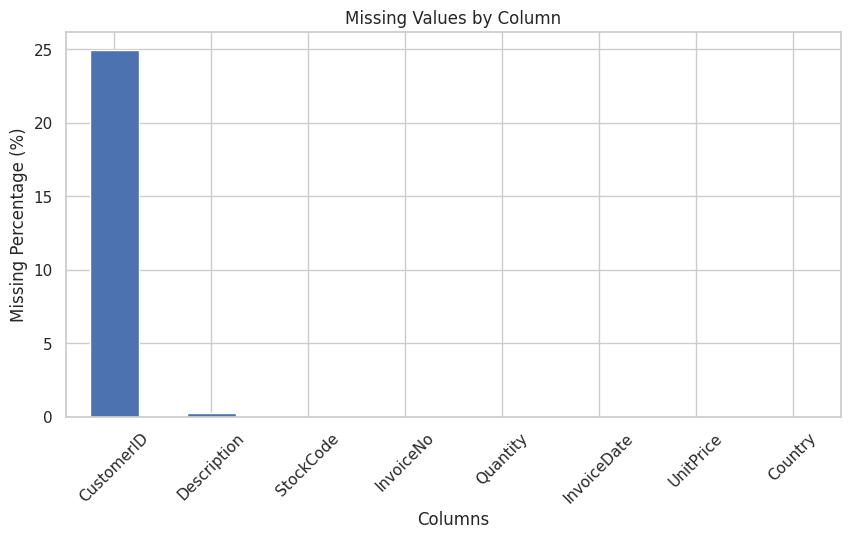

In [18]:
plt.figure(figsize=(10, 5))

missing_table["Missing Percentage"].sort_values(
    ascending=False
).plot(kind="bar")

plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Missing Percentage (%)")
plt.xticks(rotation=45)

plt.show()

In [19]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 5268


In [20]:
df[df.duplicated()].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom
587,536412,22273,FELTCRAFT DOLL MOLLY,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom
589,536412,22749,FELTCRAFT PRINCESS CHARLOTTE DOLL,1,2010-12-01 11:49:00,3.75,17920.0,United Kingdom
594,536412,22141,CHRISTMAS CRAFT TREE TOP ANGEL,1,2010-12-01 11:49:00,2.10,17920.0,United Kingdom
598,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.0,United Kingdom
600,536412,22569,FELTCRAFT CUSHION BUTTERFLY,2,2010-12-01 11:49:00,3.75,17920.0,United Kingdom


In [22]:
df = df.drop_duplicates().copy()

In [23]:
print("Duplicates after cleaning:", df.duplicated().sum())

Duplicates after cleaning: 0


In [24]:
df.dtypes

,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
UnitPrice,float64
CustomerID,float64
Country,object


In [25]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [26]:
df["InvoiceDate"].dtype

dtype('<M8[ns]')

In [27]:
print("Quantity <= 0:", (df["Quantity"] <= 0).sum())

Quantity <= 0: 10587


In [28]:
print("UnitPrice <= 0:", (df["UnitPrice"] <= 0).sum())

UnitPrice <= 0: 2512


In [29]:
df[df["UnitPrice"] <= 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom


In [30]:
df["InvoiceNo"] = df["InvoiceNo"].astype(str)

df["IsCancelled"] = df["InvoiceNo"].str.startswith("C")

In [31]:
df["IsCancelled"].value_counts()

,count
IsCancelled,
False,527390
True,9251


In [32]:
cancelled_percentage = df["IsCancelled"].mean() * 100

print(
    f"Cancelled transactions: {cancelled_percentage:.2f}%"
)

Cancelled transactions: 1.72%


In [34]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [35]:
df[[
    "Quantity",
    "UnitPrice",
    "Revenue"
]].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [37]:
sales_df = df[
    (df["Quantity"] > 0) &
    (df["UnitPrice"] > 0) &
    (~df["IsCancelled"])
].copy()

In [38]:
sales_df.shape

(524878, 10)

In [39]:
sales_df["CustomerID"].isnull().sum()

np.int64(132186)

In [40]:
customer_df = sales_df.dropna(
    subset=["CustomerID"]
).copy()

In [41]:
customer_df.shape

(392692, 10)

In [42]:
sales_df["Year"] = sales_df["InvoiceDate"].dt.year

In [43]:
sales_df["Month"] = sales_df["InvoiceDate"].dt.month

In [44]:
sales_df["MonthName"] = sales_df["InvoiceDate"].dt.month_name()

In [45]:
sales_df["Week"] = sales_df["InvoiceDate"].dt.isocalendar().week

In [46]:
sales_df["Day"] = sales_df["InvoiceDate"].dt.day

In [47]:
sales_df["Hour"] = sales_df["InvoiceDate"].dt.hour

In [48]:
sales_df["YearMonth"] = sales_df["InvoiceDate"].dt.to_period("M")

In [49]:
sales_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled,Revenue,Year,Month,MonthName,Week,Day,Hour,YearMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,False,15.30,2010,12,December,48,1,8,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34,2010,12,December,48,1,8,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,False,22.00,2010,12,December,48,1,8,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34,2010,12,December,48,1,8,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34,2010,12,December,48,1,8,2010-12


In [50]:
sales_df[
    ["Quantity", "UnitPrice", "Revenue"]
].describe()

,Quantity,UnitPrice,Revenue
count,524878.000000,524878.000000,524878.000000
mean,10.616600,3.922573,20.275399
std,156.280031,36.093028,271.693566
min,1.000000,0.001000,0.001000
25%,1.000000,1.250000,3.900000
50%,4.000000,2.080000,9.920000
75%,11.000000,4.130000,17.700000
max,80995.000000,13541.330000,168469.600000


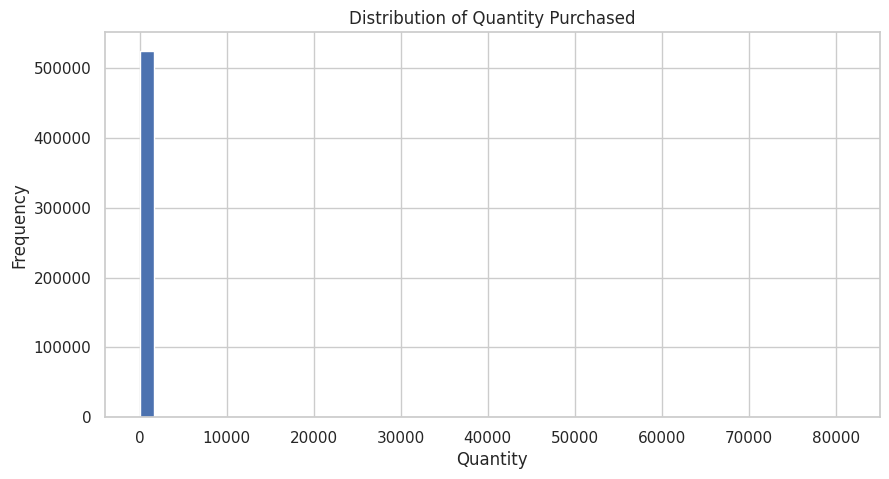

In [51]:
plt.figure(figsize=(10, 5))

plt.hist(
    sales_df["Quantity"],
    bins=50
)

plt.title("Distribution of Quantity Purchased")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.show()

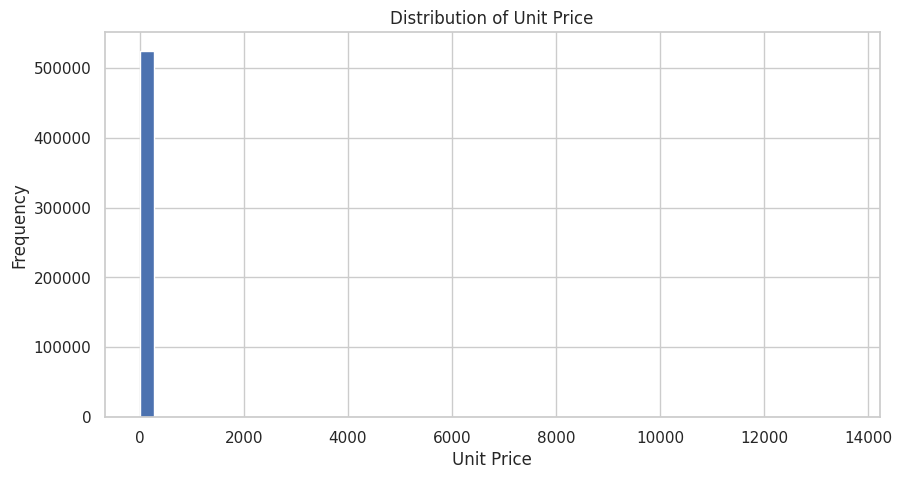

In [52]:
plt.figure(figsize=(10, 5))

plt.hist(
    sales_df["UnitPrice"],
    bins=50
)

plt.title("Distribution of Unit Price")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")

plt.show()

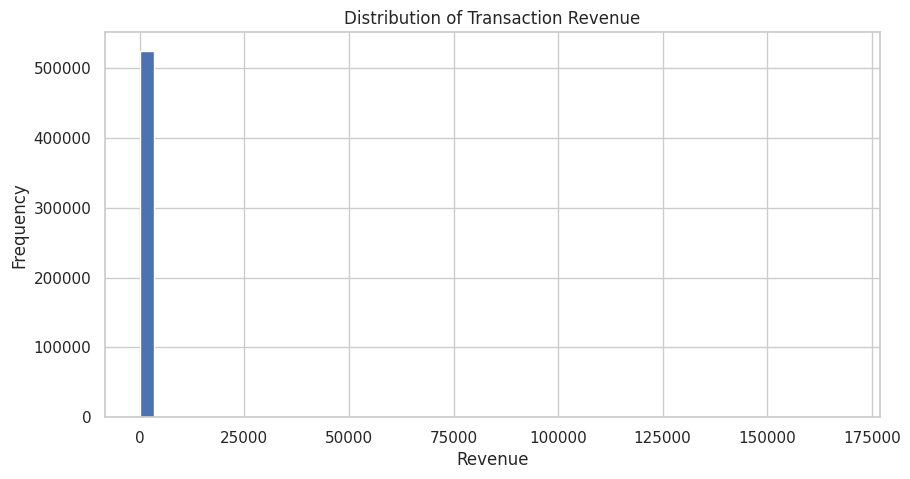

In [53]:
plt.figure(figsize=(10, 5))

plt.hist(
    sales_df["Revenue"],
    bins=50
)

plt.title("Distribution of Transaction Revenue")
plt.xlabel("Revenue")
plt.ylabel("Frequency")

plt.show()

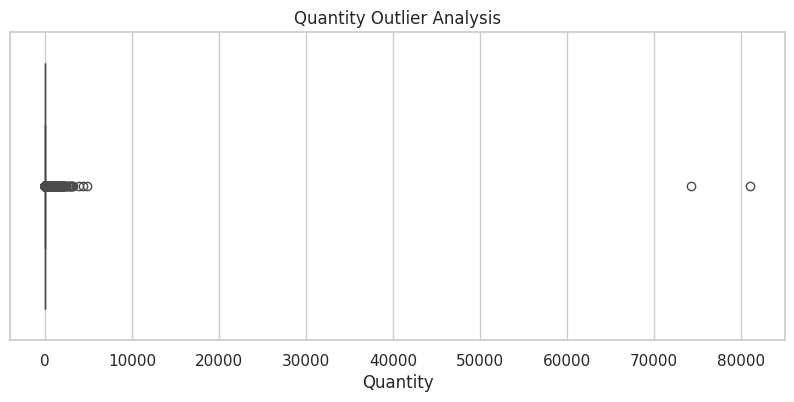

In [54]:
plt.figure(figsize=(10, 4))

sns.boxplot(x=sales_df["Quantity"])

plt.title("Quantity Outlier Analysis")
plt.xlabel("Quantity")

plt.show()

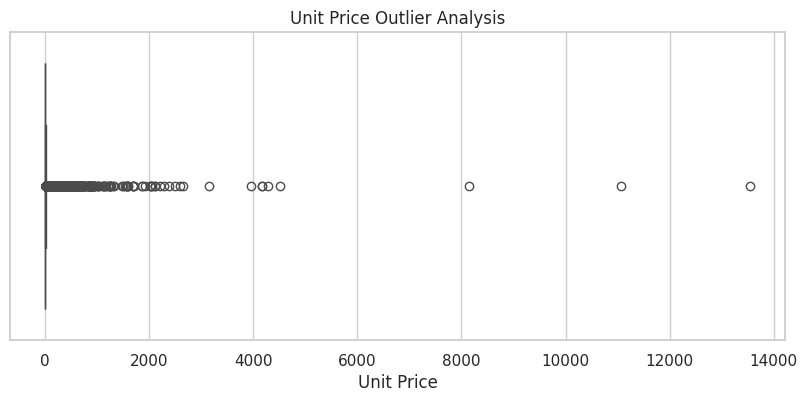

In [55]:
plt.figure(figsize=(10, 4))

sns.boxplot(x=sales_df["UnitPrice"])

plt.title("Unit Price Outlier Analysis")
plt.xlabel("Unit Price")

plt.show()

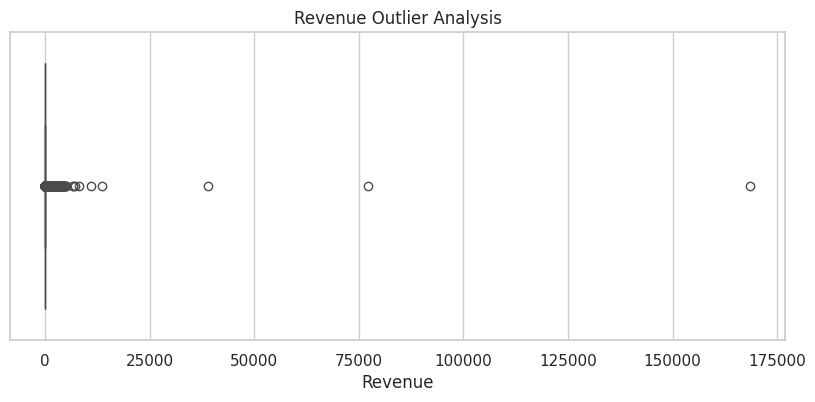

In [56]:
plt.figure(figsize=(10, 4))

sns.boxplot(x=sales_df["Revenue"])

plt.title("Revenue Outlier Analysis")
plt.xlabel("Revenue")

plt.show()

In [57]:
Q1 = sales_df["Quantity"].quantile(0.25)
Q3 = sales_df["Quantity"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

quantity_outliers = sales_df[
    (sales_df["Quantity"] < lower_bound) |
    (sales_df["Quantity"] > upper_bound)
]

print("Quantity outliers:", len(quantity_outliers))

Quantity outliers: 27111


In [58]:
Q1_price = sales_df["UnitPrice"].quantile(0.25)
Q3_price = sales_df["UnitPrice"].quantile(0.75)

IQR_price = Q3_price - Q1_price

lower_price = Q1_price - 1.5 * IQR_price
upper_price = Q3_price + 1.5 * IQR_price

price_outliers = sales_df[
    (sales_df["UnitPrice"] < lower_price) |
    (sales_df["UnitPrice"] > upper_price)
]

print("Unit price outliers:", len(price_outliers))

Unit price outliers: 37827


In [59]:
product_revenue = (
    sales_df
    .groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

product_revenue.head(10)

,Revenue
Description,
DOTCOM POSTAGE,206248.77
REGENCY CAKESTAND 3 TIER,174156.54
"PAPER CRAFT , LITTLE BIRDIE",168469.60
WHITE HANGING HEART T-LIGHT HOLDER,106236.72
PARTY BUNTING,99445.23
JUMBO BAG RED RETROSPOT,94159.81
MEDIUM CERAMIC TOP STORAGE JAR,81700.92
POSTAGE,78101.88
Manual,77752.82


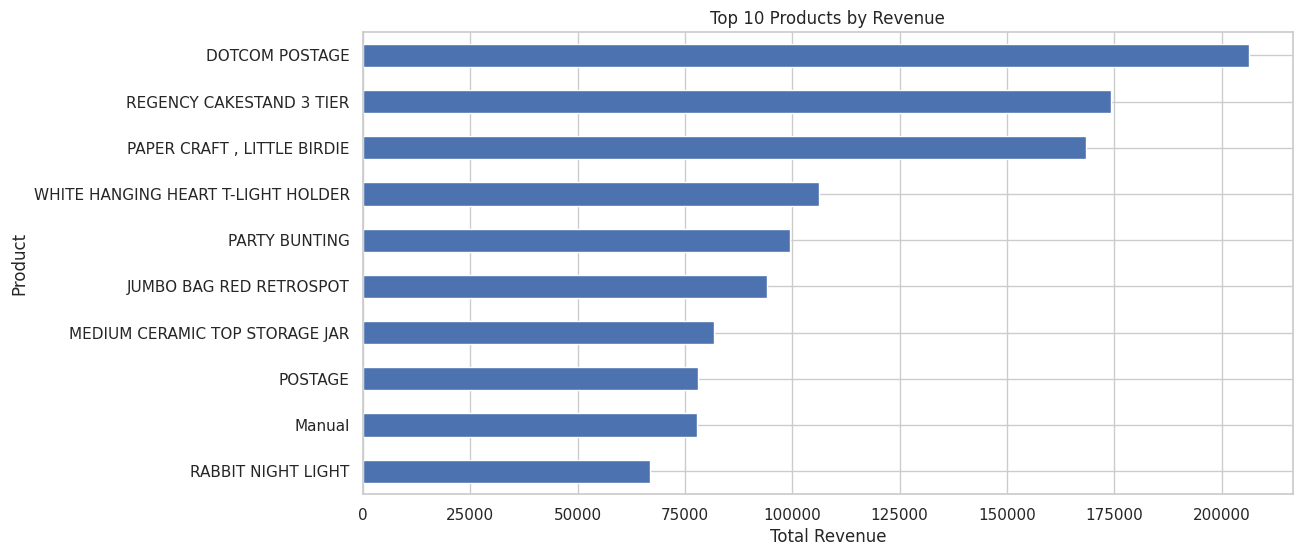

In [60]:
plt.figure(figsize=(12, 6))

product_revenue.head(10).sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Product")

plt.show()

In [61]:
country_revenue = (
    sales_df
    .groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

country_revenue.head(10)

,Revenue
Country,
United Kingdom,9001744.094
Netherlands,285446.340
EIRE,283140.520
Germany,228678.400
France,209625.370
Australia,138453.810
Spain,61558.560
Switzerland,57067.600
Belgium,41196.340


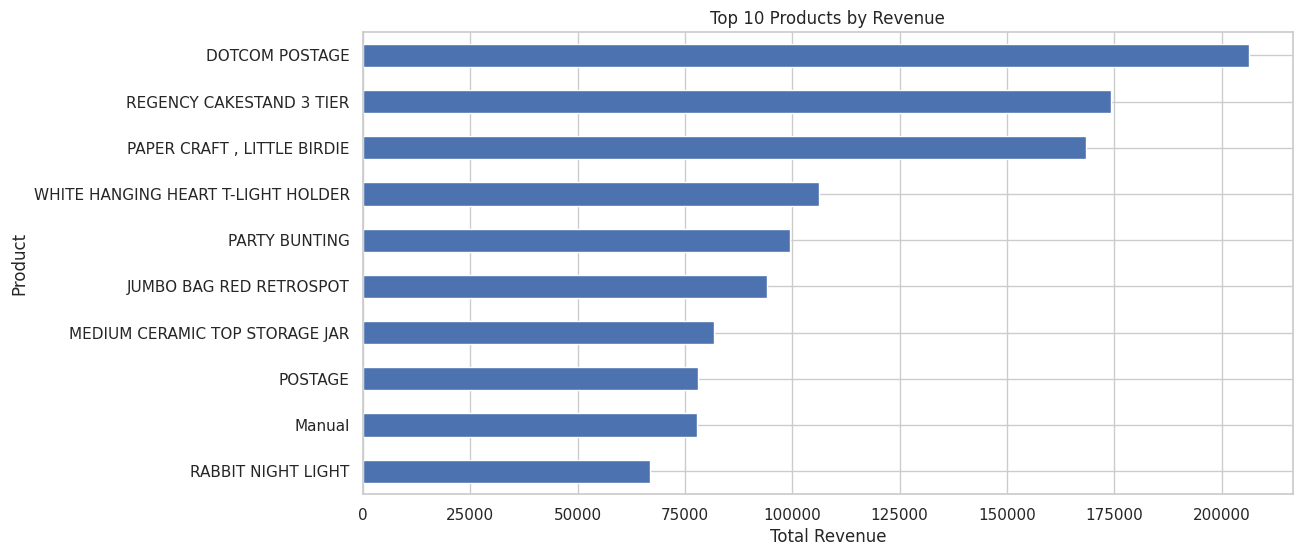

In [65]:
plt.figure(figsize=(12, 6))

product_revenue.head(10).sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Product")

plt.show()

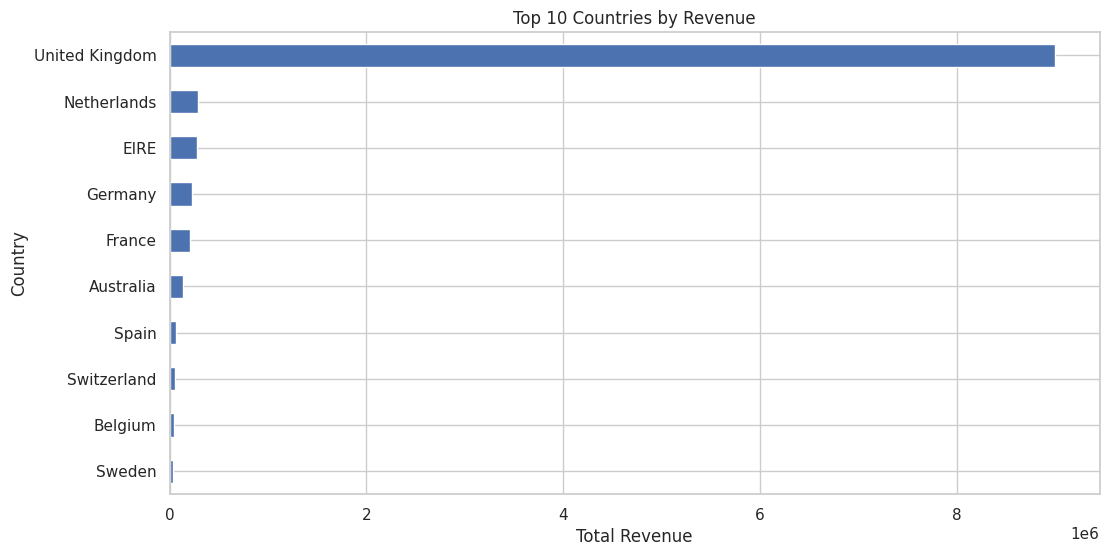

In [62]:
plt.figure(figsize=(12, 6))

country_revenue.head(10).sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Country")

plt.show()

In [70]:
weekly_sales = (
    sales_df
    .groupby(
        sales_df["InvoiceDate"].dt.to_period("W")
    )["Revenue"]
    .sum()
)

In [72]:
monthly_sales = (
    sales_df.groupby(
        sales_df["InvoiceDate"].dt.to_period("M")
    )["Revenue"]
    .sum()
)

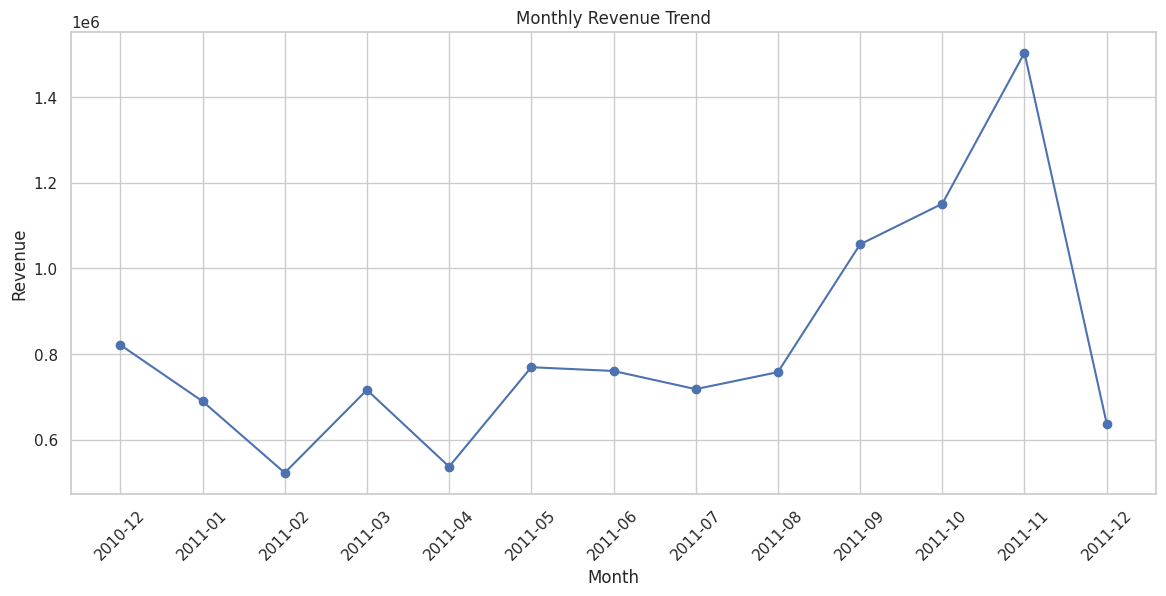

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

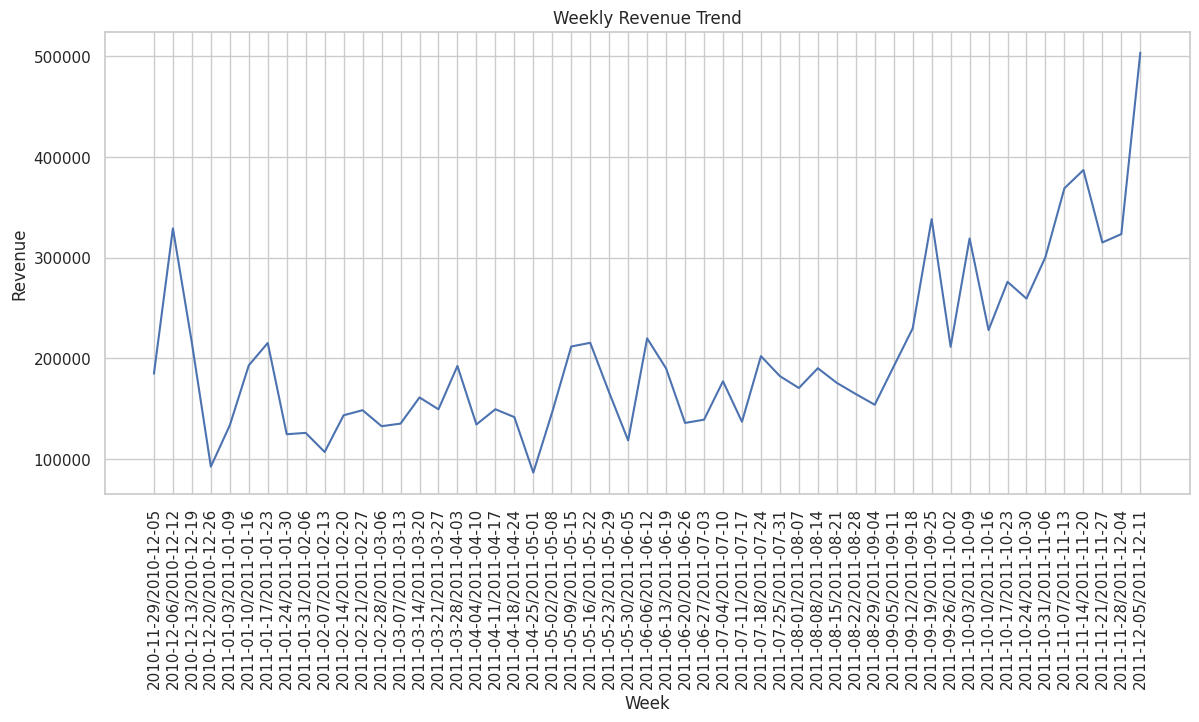

In [74]:
plt.figure(figsize=(14, 6))

plt.plot(
    weekly_sales.index.astype(str),
    weekly_sales.values
)

plt.title("Weekly Revenue Trend")
plt.xlabel("Week")
plt.ylabel("Revenue")

plt.xticks(rotation=90)

plt.show()

In [76]:
product_quantity = (
    sales_df
    .groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

product_quantity.head(10)

,Quantity
Description,
"PAPER CRAFT , LITTLE BIRDIE",80995
MEDIUM CERAMIC TOP STORAGE JAR,78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951
JUMBO BAG RED RETROSPOT,48371
WHITE HANGING HEART T-LIGHT HOLDER,37872
POPCORN HOLDER,36749
PACK OF 72 RETROSPOT CAKE CASES,36396
ASSORTED COLOUR BIRD ORNAMENT,36362
RABBIT NIGHT LIGHT,30739


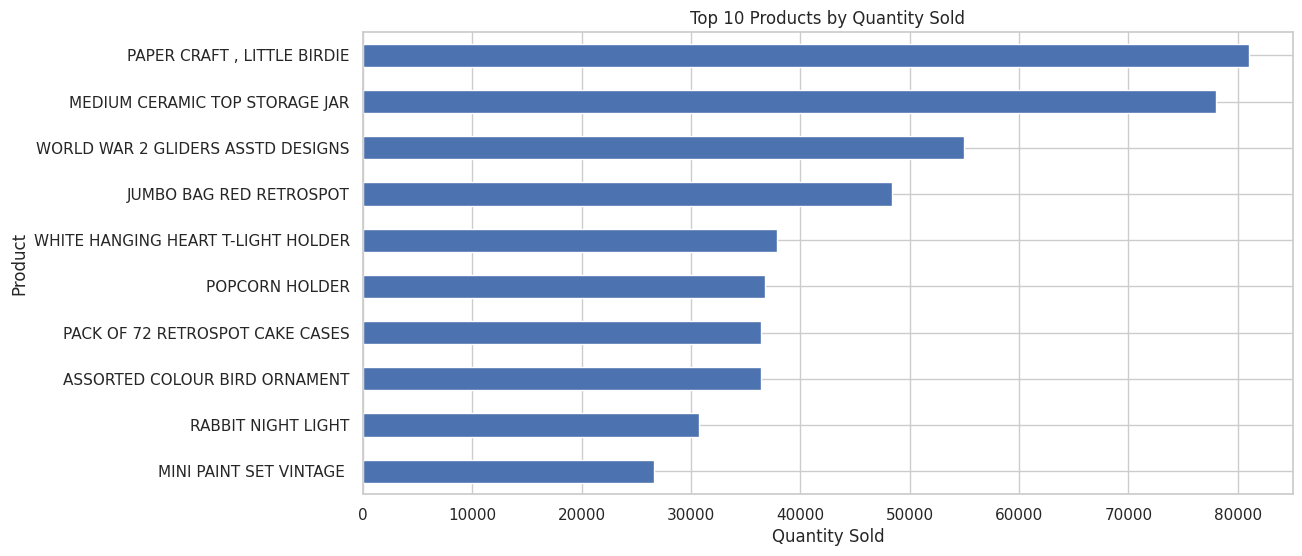

In [77]:
plt.figure(figsize=(12, 6))

product_quantity.head(10).sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")

plt.show()

In [78]:
order_value = (
    sales_df
    .groupby("InvoiceNo")["Revenue"]
    .sum()
)

In [79]:
average_order_value = order_value.mean()

print(
    f"Average Order Value: {average_order_value:.2f}"
)

Average Order Value: 533.17


In [80]:
print("Number of unique orders:", sales_df["InvoiceNo"].nunique())

Number of unique orders: 19960


In [81]:
customer_summary = (
    customer_df
    .groupby("CustomerID")
    .agg(
        Total_Revenue=("Revenue", "sum"),
        Total_Orders=("InvoiceNo", "nunique"),
        Total_Quantity=("Quantity", "sum")
    )
)

In [82]:
customer_summary["Average_Order_Value"] = (
    customer_summary["Total_Revenue"] /
    customer_summary["Total_Orders"]
)

In [83]:
customer_summary.sort_values(
    "Total_Revenue",
    ascending=False
).head(10)

,Total_Revenue,Total_Orders,Total_Quantity,Average_Order_Value
CustomerID,,,,
14646.0,280206.02,73,196915,3838.438630
18102.0,259657.30,60,64124,4327.621667
17450.0,194390.79,46,69973,4225.886739
16446.0,168472.50,2,80997,84236.250000
14911.0,143711.17,201,80240,714.980945
12415.0,124914.53,21,77374,5948.310952
14156.0,117210.08,55,57768,2131.092364
17511.0,91062.38,31,64549,2937.496129
16029.0,80850.84,63,40108,1283.346667


In [84]:
top_customers = (
    customer_summary
    .sort_values(
        "Total_Revenue",
        ascending=False
    )
    .head(10)
)

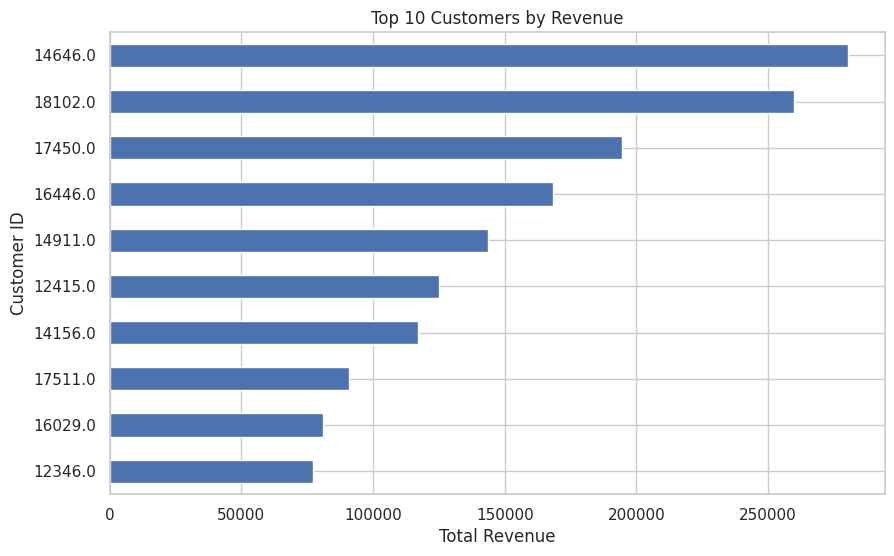

In [85]:
plt.figure(figsize=(10, 6))

top_customers["Total_Revenue"].sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Customer ID")

plt.show()

In [86]:
sales_df.sort_values(
    "Revenue",
    ascending=False
).head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled,Revenue,Year,Month,MonthName,Week,Day,Hour,YearMonth
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom,False,168469.60,2011,12,December,49,9,9,2011-12
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,False,77183.60,2011,1,January,3,18,10,2011-01
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,2011-06-10 15:28:00,649.50,15098.0,United Kingdom,False,38970.00,2011,6,June,23,10,15,2011-06
15017,537632,AMAZONFEE,AMAZON FEE,1,2010-12-07 15:08:00,13541.33,NaN,United Kingdom,False,13541.33,2010,12,December,49,7,15,2010-12
299982,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom,False,11062.06,2011,8,August,32,12,14,2011-08
173382,551697,POST,POSTAGE,1,2011-05-03 13:46:00,8142.75,16029.0,United Kingdom,False,8142.75,2011,5,May,18,3,13,2011-05
348325,567423,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,2011-09-20 11:05:00,5.06,17450.0,United Kingdom,False,7144.72,2011,9,September,38,20,11,2011-09
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-04-18 13:20:00,2.10,15749.0,United Kingdom,False,6539.40,2011,4,April,16,18,13,2011-04
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-01-11 12:55:00,2.10,15749.0,United Kingdom,False,6539.40,2011,1,January,2,11,12,2011-01
421601,573003,23084,RABBIT NIGHT LIGHT,2400,2011-10-27 12:11:00,2.08,14646.0,Netherlands,False,4992.00,2011,10,October,43,27,12,2011-10


In [89]:
sales_df.sort_values(
    "UnitPrice",
    ascending=False
).head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled,Revenue,Year,Month,MonthName,Week,Day,Hour,YearMonth
15017,537632,AMAZONFEE,AMAZON FEE,1,2010-12-07 15:08:00,13541.33,NaN,United Kingdom,False,13541.33,2010,12,December,49,7,15,2010-12
299982,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom,False,11062.06,2011,8,August,32,12,14,2011-08
173382,551697,POST,POSTAGE,1,2011-05-03 13:46:00,8142.75,16029.0,United Kingdom,False,8142.75,2011,5,May,18,3,13,2011-05
297723,562955,DOT,DOTCOM POSTAGE,1,2011-08-11 10:14:00,4505.17,NaN,United Kingdom,False,4505.17,2011,8,August,32,11,10,2011-08
268028,560373,M,Manual,1,2011-07-18 12:30:00,4287.63,NaN,United Kingdom,False,4287.63,2011,7,July,29,18,12,2011-07
422351,573077,M,Manual,1,2011-10-27 14:13:00,4161.06,12536.0,France,False,4161.06,2011,10,October,43,27,14,2011-10
422376,573080,M,Manual,1,2011-10-27 14:20:00,4161.06,12536.0,France,False,4161.06,2011,10,October,43,27,14,2011-10
406406,571751,M,Manual,1,2011-10-19 11:18:00,3949.32,12744.0,Singapore,False,3949.32,2011,10,October,42,19,11,2011-10
374542,569382,M,Manual,1,2011-10-03 16:44:00,3155.95,15502.0,United Kingdom,False,3155.95,2011,10,October,40,3,16,2011-10
347948,567353,M,Manual,1,2011-09-19 16:14:00,2653.95,NaN,Hong Kong,False,2653.95,2011,9,September,38,19,16,2011-09


In [90]:
total_transactions = len(df)

cancelled_transactions = df["IsCancelled"].sum()

cancelled_percentage = (
    cancelled_transactions /
    total_transactions
) * 100

print("Total transactions:", total_transactions)
print("Cancelled transactions:", cancelled_transactions)
print(
    f"Cancelled percentage: {cancelled_percentage:.2f}%"
)

Total transactions: 536641
Cancelled transactions: 9251
Cancelled percentage: 1.72%


In [88]:
sales_df.sort_values(
    "Quantity",
    ascending=False
).head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled,Revenue,Year,Month,MonthName,Week,Day,Hour,YearMonth
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom,False,168469.60,2011,12,December,49,9,9,2011-12
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,False,77183.60,2011,1,January,3,18,10,2011-01
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,2011-10-27 12:26:00,0.21,12901.0,United Kingdom,False,1008.00,2011,10,October,43,27,12,2011-10
206121,554868,22197,SMALL POPCORN HOLDER,4300,2011-05-27 10:52:00,0.72,13135.0,United Kingdom,False,3096.00,2011,5,May,21,27,10,2011-05
97432,544612,22053,EMPIRE DESIGN ROSETTE,3906,2011-02-22 10:43:00,0.82,18087.0,United Kingdom,False,3202.92,2011,2,February,8,22,10,2011-02
270885,560599,18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,3186,2011-07-19 17:04:00,0.06,14609.0,United Kingdom,False,191.16,2011,7,July,29,19,17,2011-07
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-04-18 13:20:00,2.10,15749.0,United Kingdom,False,6539.40,2011,4,April,16,18,13,2011-04
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-01-11 12:55:00,2.10,15749.0,United Kingdom,False,6539.40,2011,1,January,2,11,12,2011-01
433788,573995,16014,SMALL CHINESE STYLE SCISSOR,3000,2011-11-02 11:24:00,0.32,16308.0,United Kingdom,False,960.00,2011,11,November,44,2,11,2011-11
4945,536830,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,2880,2010-12-02 17:38:00,0.18,16754.0,United Kingdom,False,518.40,2010,12,December,48,2,17,2010-12


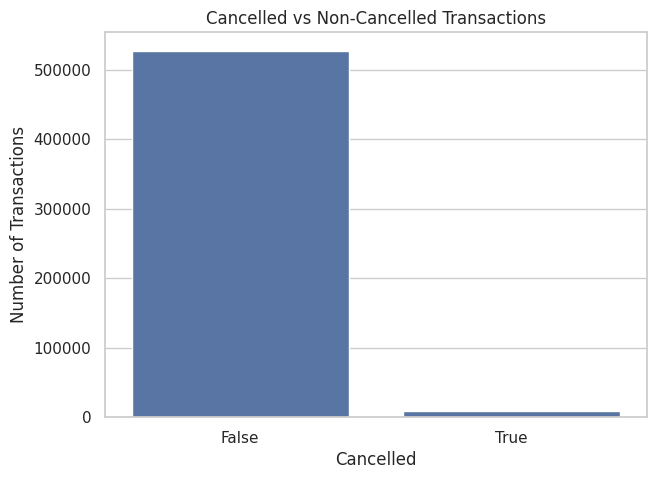

In [91]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="IsCancelled"
)

plt.title("Cancelled vs Non-Cancelled Transactions")
plt.xlabel("Cancelled")
plt.ylabel("Number of Transactions")

plt.show()

In [92]:
top_countries = (
    sales_df["Country"]
    .value_counts()
    .head(10)
)

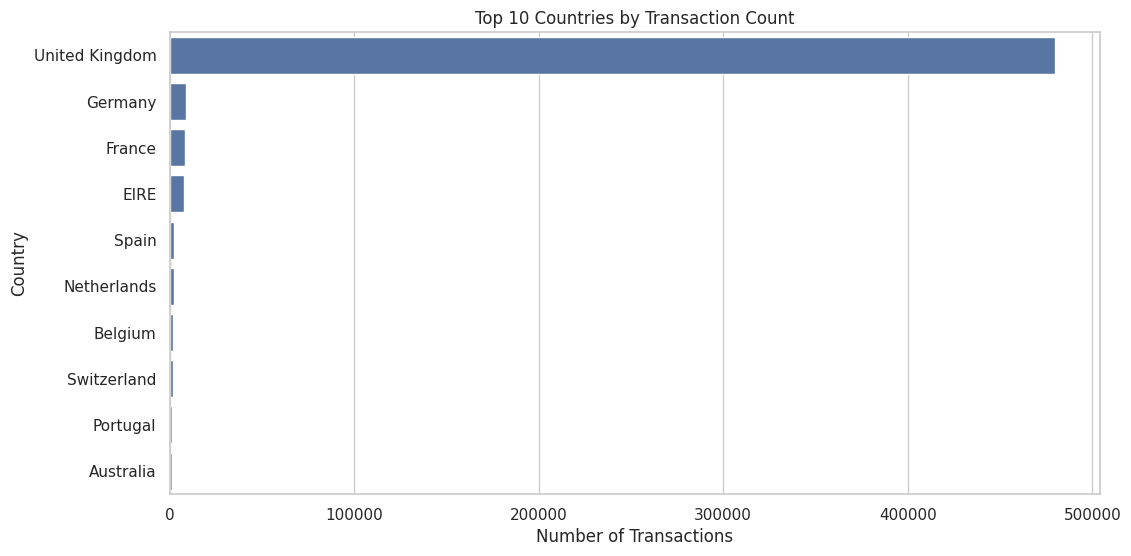

In [93]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title("Top 10 Countries by Transaction Count")
plt.xlabel("Number of Transactions")
plt.ylabel("Country")

plt.show()

In [94]:
top_5_products = (
    product_quantity
    .head(5)
    .index
)

top_5_products

Index(['PAPER CRAFT , LITTLE BIRDIE', 'MEDIUM CERAMIC TOP STORAGE JAR',
       'WORLD WAR 2 GLIDERS ASSTD DESIGNS', 'JUMBO BAG RED RETROSPOT',
       'WHITE HANGING HEART T-LIGHT HOLDER'],
      dtype='object', name='Description')

In [95]:
product_monthly = (
    sales_df[
        sales_df["Description"].isin(top_5_products)
    ]
    .groupby(
        ["YearMonth", "Description"]
    )["Quantity"]
    .sum()
    .reset_index()
)

In [97]:
product_monthly["Quantity"] = pd.to_numeric(
    product_monthly["Quantity"], errors="coerce"
)

In [98]:
product_monthly = product_monthly.dropna(subset=["Quantity"])

In [100]:
print(product_monthly.dtypes)
print(product_monthly["Quantity"].head(20))

YearMonth      period[M]
Description       object
Quantity           int64
dtype: object
0      2151
1      3870
2      5195
3      2747
4     74215
5      5535
6      1492
7      3080
8      1877
9      3518
10     5280
11     1998
12     3888
13     2456
14     3843
15    10239
16     3621
17      801
18     4036
19     4949
Name: Quantity, dtype: int64


In [101]:
product_monthly["YearMonth"] = product_monthly["YearMonth"].astype(str)

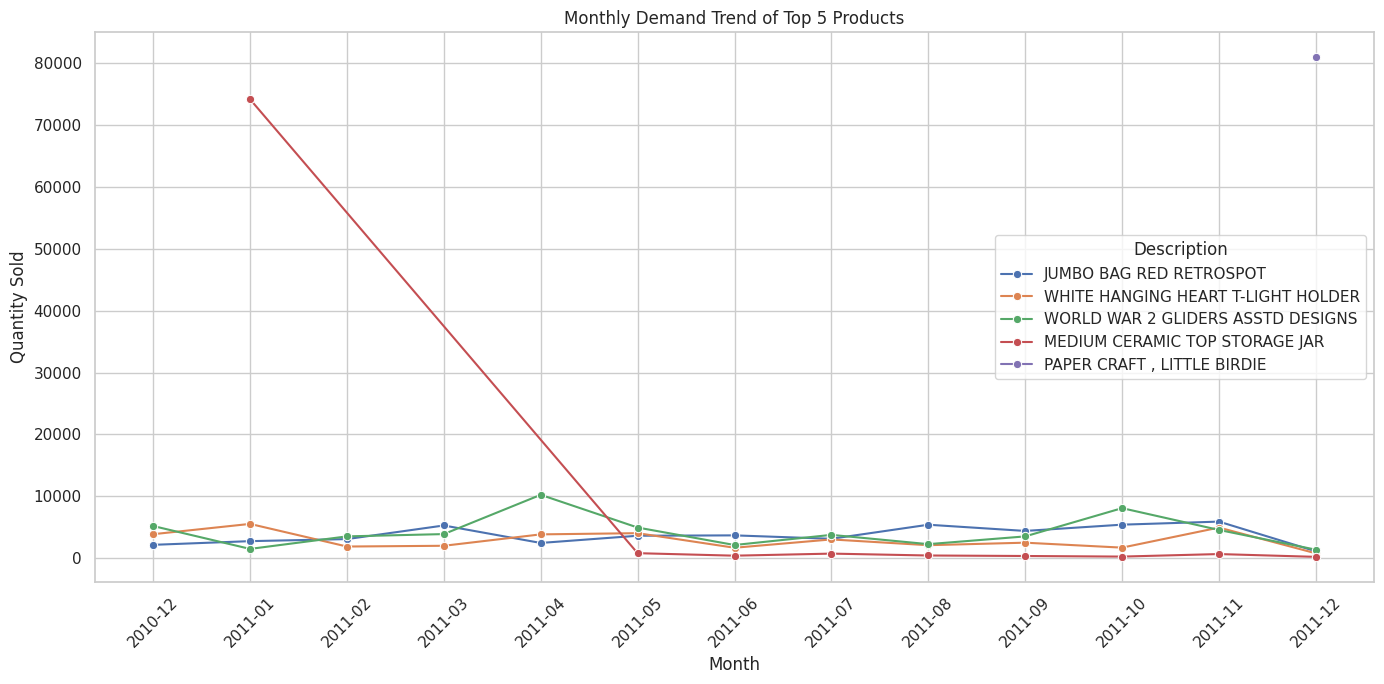

In [102]:
plt.figure(figsize=(14, 7))

sns.lineplot(
    data=product_monthly,
    x="YearMonth",
    y="Quantity",
    hue="Description",
    marker="o"
)

plt.title("Monthly Demand Trend of Top 5 Products")
plt.xlabel("Month")
plt.ylabel("Quantity Sold")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

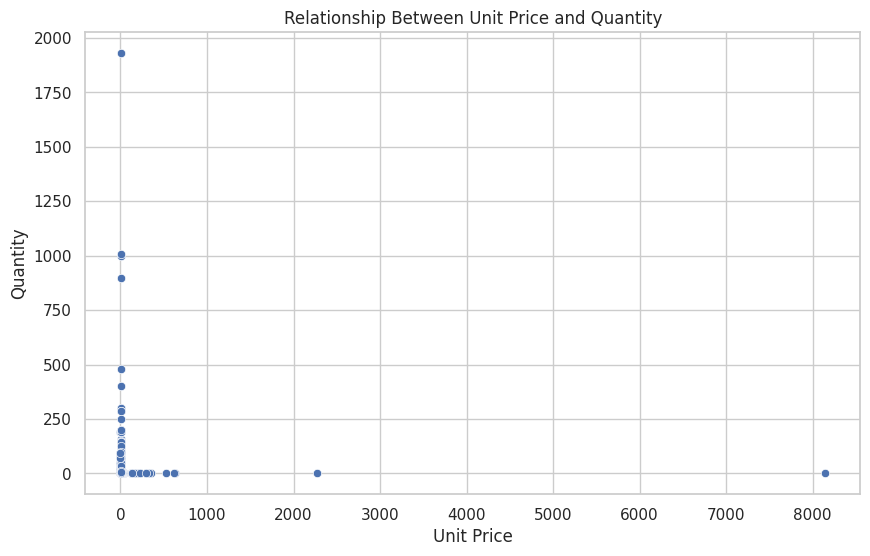

In [103]:
sample_df = sales_df.sample(
    min(5000, len(sales_df)),
    random_state=42
)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=sample_df,
    x="UnitPrice",
    y="Quantity"
)

plt.title(
    "Relationship Between Unit Price and Quantity"
)

plt.xlabel("Unit Price")
plt.ylabel("Quantity")

plt.show()

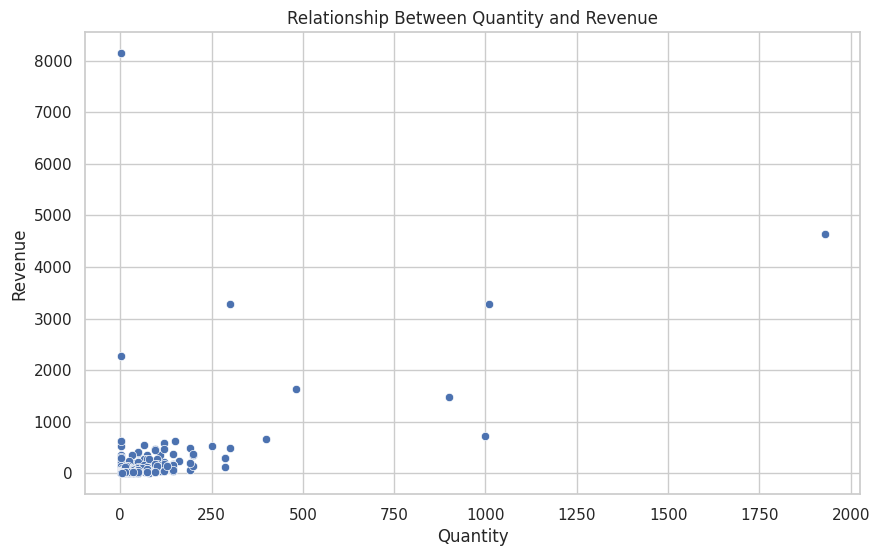

In [104]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=sample_df,
    x="Quantity",
    y="Revenue"
)

plt.title(
    "Relationship Between Quantity and Revenue"
)

plt.xlabel("Quantity")
plt.ylabel("Revenue")

plt.show()

In [105]:
correlation = sales_df[
    [
        "Quantity",
        "UnitPrice",
        "Revenue"
    ]
].corr()

correlation

,Quantity,UnitPrice,Revenue
Quantity,1.000000,-0.003788,0.907402
UnitPrice,-0.003788,1.000000,0.137381
Revenue,0.907402,0.137381,1.000000


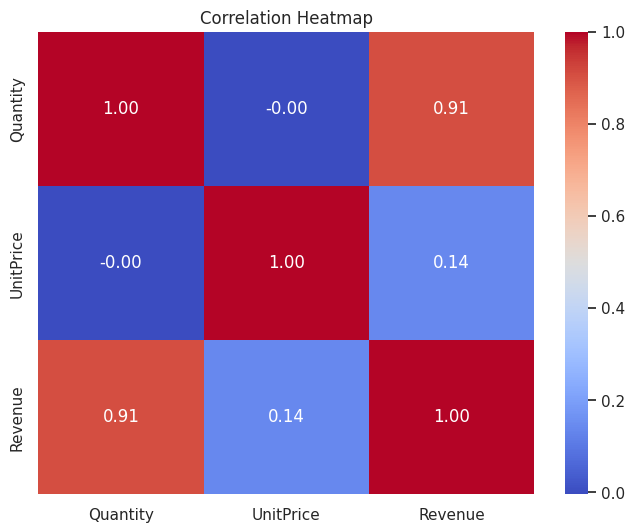

In [106]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [107]:
hourly_revenue = (
    sales_df
    .groupby("Hour")["Revenue"]
    .sum()
)

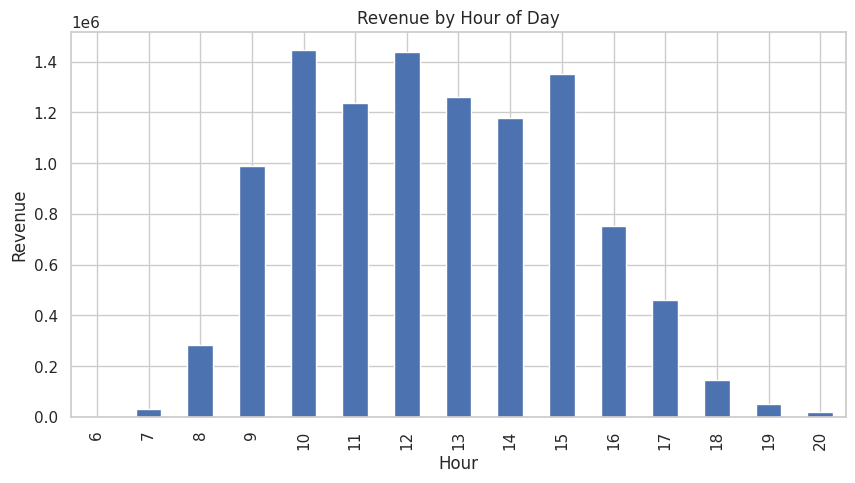

In [108]:
plt.figure(figsize=(10, 5))

hourly_revenue.plot(
    kind="bar"
)

plt.title("Revenue by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Revenue")

plt.show()

In [109]:
country_percentage = (
    country_revenue /
    country_revenue.sum()
) * 100

country_percentage.head(10)

,Revenue
Country,
United Kingdom,84.586078
Netherlands,2.682234
EIRE,2.660567
Germany,2.148807
France,1.969772
Australia,1.301000
Spain,0.578443
Switzerland,0.536243
Belgium,0.387107


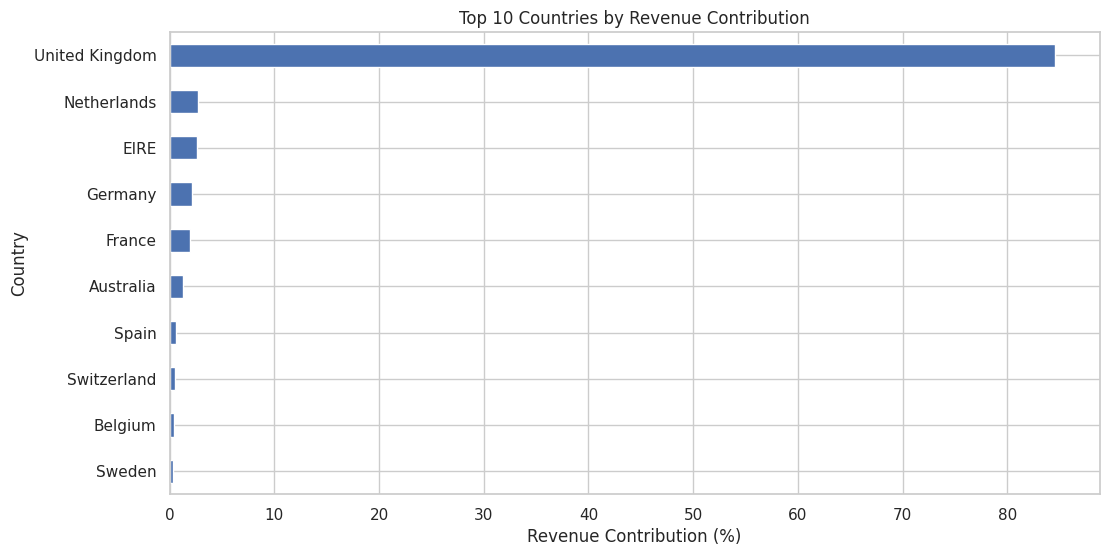

In [110]:
plt.figure(figsize=(12, 6))

country_percentage.head(10).sort_values().plot(
    kind="barh"
)

plt.title(
    "Top 10 Countries by Revenue Contribution"
)

plt.xlabel("Revenue Contribution (%)")
plt.ylabel("Country")

plt.show()

In [111]:
customer_analysis = customer_df.groupby(
    "CustomerID"
).agg(
    Total_Revenue=("Revenue", "sum"),
    Total_Quantity=("Quantity", "sum"),
    Total_Orders=("InvoiceNo", "nunique")
)

In [112]:
customer_analysis.head()

,Total_Revenue,Total_Quantity,Total_Orders
CustomerID,,,
12346.0,77183.60,74215,1
12347.0,4310.00,2458,7
12348.0,1797.24,2341,4
12349.0,1757.55,631,1
12350.0,334.40,197,1


In [113]:
customer_analysis["Average_Order_Value"] = (
    customer_analysis["Total_Revenue"] /
    customer_analysis["Total_Orders"]
)

In [114]:
customer_analysis.sort_values(
    "Total_Revenue",
    ascending=False
).head(10)

,Total_Revenue,Total_Quantity,Total_Orders,Average_Order_Value
CustomerID,,,,
14646.0,280206.02,196915,73,3838.438630
18102.0,259657.30,64124,60,4327.621667
17450.0,194390.79,69973,46,4225.886739
16446.0,168472.50,80997,2,84236.250000
14911.0,143711.17,80240,201,714.980945
12415.0,124914.53,77374,21,5948.310952
14156.0,117210.08,57768,55,2131.092364
17511.0,91062.38,64549,31,2937.496129
16029.0,80850.84,40108,63,1283.346667


In [115]:
summary = {
    "Total Rows After Cleaning": len(sales_df),
    "Unique Products": sales_df["Description"].nunique(),
    "Unique Countries": sales_df["Country"].nunique(),
    "Unique Customers": customer_df["CustomerID"].nunique(),
    "Unique Orders": sales_df["InvoiceNo"].nunique(),
    "Total Revenue": sales_df["Revenue"].sum(),
    "Average Order Value": order_value.mean(),
    "Cancelled Percentage": cancelled_percentage
}

summary_df = pd.DataFrame(
    summary.items(),
    columns=["Metric", "Value"]
)

summary_df

,Metric,Value
0,Total Rows After Cleaning,5.248780e+05
1,Unique Products,4.026000e+03
2,Unique Countries,3.800000e+01
3,Unique Customers,4.338000e+03
4,Unique Orders,1.996000e+04
5,Total Revenue,1.064211e+07
6,Average Order Value,5.331719e+02
7,Cancelled Percentage,1.723871e+00
